## SIMPLE CNN

In [ ]:

# =========================
# Cell 1 — Imports & config
# =========================
import os, json
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# Repro
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Paths
DATA_DIR   = Path("data") / "dataset"   # expects: data/dataset/real, data/dataset/fake
MODELS_DIR = Path("models"); MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "deepfake_simplecnn.keras"
LABELS_JSON = Path("labels.json")

# Training config
IMG_SIZE = (160, 160)   # ↑ from 128 → usually a free accuracy bump; drop back to (128,128) if RAM is tight
BATCH    = 32           # use 16 if you see OOM
EPOCHS   = 20           # give it time; EarlyStopping will cut it short if needed


In [ ]:
# =========================
# Cell 2 — Data pipelines
# =========================
# Stronger, realistic augments for deepfake artifacts
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    shear_range=10,
    zoom_range=[0.9, 1.1],
    brightness_range=[0.8, 1.2],
    channel_shift_range=10.0,
    horizontal_flip=True,
    fill_mode="nearest"
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR.as_posix(),
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    subset="training",
    seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    DATA_DIR.as_posix(),
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    subset="validation",
    seed=SEED,
    shuffle=False
)

# Persist label mapping for app inference
class_indices = train_gen.class_indices  # e.g., {'fake': 0, 'real': 1}
with open(LABELS_JSON, "w") as f:
    json.dump(class_indices, f, indent=2)
print("Saved label mapping to", LABELS_JSON.resolve())

# --- Class weights (helps if Fake/Real are imbalanced) ---
from collections import Counter
cnt = Counter(train_gen.classes)  # {0: count_fake, 1: count_real}
total = sum(cnt.values())
class_weight = {cls: total / (2.0 * cnt[cls]) for cls in cnt}
print("Class weights:", class_weight)


Found 16002 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Saved label mapping to D:\Mtech\Research paper\DeepFake Detection\Minor Version\labels.json
Class weights: {np.int32(0): 1.0, np.int32(1): 1.0}


In [ ]:
# =========================
# Cell 3 — Simple CNN model (upgraded)
# =========================
def conv_block(x, filters, l2w=1e-4, p_drop=0.1):
    x = layers.Conv2D(filters, 3, padding="same",
                      kernel_regularizer=keras.regularizers.l2(l2w))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SeparableConv2D(filters, 3, padding="same",
                               depthwise_regularizer=keras.regularizers.l2(l2w),
                               pointwise_regularizer=keras.regularizers.l2(l2w))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(p_drop)(x)
    return x

def build_simple_cnn(input_shape=(160,160,3)):
    i = layers.Input(shape=input_shape)
    # light noise helps generalization on compression artifacts
    x = layers.GaussianNoise(0.02)(i)

    x = conv_block(x, 32, 1e-4, 0.10)
    x = conv_block(x, 64, 1e-4, 0.15)
    x = conv_block(x, 128, 1e-4, 0.20)
    x = conv_block(x, 192, 1e-4, 0.25)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    o = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(i, o, name="SimpleCNN_Upgraded")

model = build_simple_cnn(input_shape=(*IMG_SIZE, 3))
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),  # steadier than 1e-3 here
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=[keras.metrics.AUC(name="auc"), keras.metrics.BinaryAccuracy(name="accuracy")]
)
model.summary()


Model: "SimpleCNN_Upgraded"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_28 (ReLU)                 │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 160, 160, 32)   │         1,344 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_29 (ReLU)                 │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 80, 80, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_30 (ReLU)                 │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 80, 80, 64)     │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_31 (ReLU)                 │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 40, 40, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 405,313 (1.55 MB)

 Trainable params: 403,649 (1.54 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [29]:
# =========================
# Cell 4 — Callbacks
# =========================
cbs = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH.as_posix(), monitor="val_auc", mode="max",
        save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, verbose=1, min_lr=1e-6
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=6,
        restore_best_weights=True, verbose=1
    ),
]



In [31]:
# # =========================
# # Cell 5 — Train
# # =========================
# history = model.fit(
#     train_gen,
#     validation_data=val_gen,
#     epochs=EPOCHS,
#     callbacks=cbs,
#     verbose=1
# )

# # Save final (best already saved by checkpoint)
# model.save(MODEL_PATH.as_posix())
# print("Saved model to:", MODEL_PATH.resolve())

# =========================
# Cell 5 — Train (no workers/use_multiprocessing)
# =========================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=cbs,
    class_weight=class_weight,
    verbose=1
)

# Save final (best already saved by checkpoint)
model.save(MODEL_PATH.as_posix())
print("Saved model to:", MODEL_PATH.resolve())


c:\Users\LOQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 972ms/step - accuracy: 0.5223 - auc: 0.5299 - loss: 0.8361
Epoch 1: val_auc improved from -inf to 0.69321, saving model to models/deepfake_simplecnn.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 538s 1s/step - accuracy: 0.5223 - auc: 0.5299 - loss: 0.8360 - val_accuracy: 0.5010 - val_auc: 0.6932 - val_loss: 0.7810 - learning_rate: 3.0000e-04
Epoch 2/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 935ms/step - accuracy: 0.5675 - auc: 0.5931 - loss: 0.7705
Epoch 2: val_auc improved from 0.69321 to 0.76668, saving model to models/deepfake_simplecnn.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 492s 982ms/step - accuracy: 0.5675 - auc: 0.5931 - loss: 0.7704 - val_accuracy: 0.6957 - val_auc: 0.7667 - val_loss: 0.7157 - learning_rate: 3.0000e-04
Epoch 3/20
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 948ms/step - accuracy: 0.6202 - auc: 0.6590 - loss: 0.7402
Epoch 3: val_auc improved from 0.76668 to 0.85154, saving model to models/deepfake_simplecnn.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 498s 994ms/s

In [54]:
# =========================
# Cell 6 — Evaluation (optional)
# =========================
val_gen.reset()
y_true = val_gen.classes
y_prob = model.predict(val_gen, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nConfusion Matrix")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report")
# Map numeric -> class names for printing
inv_map = {v:k for k,v in class_indices.items()}
target_names = [inv_map[i] for i in sorted(inv_map.keys())]
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))



Confusion Matrix
[[1848  152]
 [ 562 1438]]

Classification Report
              precision    recall  f1-score   support

        Fake     0.7668    0.9240    0.8381      2000
        Real     0.9044    0.7190    0.8011      2000

    accuracy                         0.8215      4000
   macro avg     0.8356    0.8215    0.8196      4000
weighted avg     0.8356    0.8215    0.8196      4000



## XceptionNET - Transfer Learning


In [55]:
# =====================================
# Cell 1 — Imports & Xception config
# (Run even if Part A was executed)
# =====================================
import os, json
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

DATA_DIR   = Path("data") / "dataset"
MODELS_DIR = Path("models"); MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "deepfake_xception.keras"
LABELS_JSON = Path("labels.json")

IMG_SIZE = (299, 299)   # Xception’s native size
BATCH    = 16           # Larger input → reduce batch if needed
EPOCHS_HEAD = 10        # train head - 6
EPOCHS_FT   = 10        # fine-tune - 6
BASE_LR     = 1e-3
FT_LR       = 1e-4


In [56]:
# =====================================
# Cell 2 — Data pipelines (with preprocess_input)
# =====================================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # replaces rescale=1/255
    validation_split=0.2,
    rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR.as_posix(),
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    subset="training",
    seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    DATA_DIR.as_posix(),
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    subset="validation",
    seed=SEED,
    shuffle=False
)

# Persist label mapping (reuse same labels.json path)
class_indices = train_gen.class_indices
with open(LABELS_JSON, "w") as f:
    json.dump(class_indices, f, indent=2)
print("Saved label mapping to", LABELS_JSON.resolve())


Found 16002 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.
Saved label mapping to D:\Mtech\Research paper\DeepFake Detection\Minor Version\labels.json


In [57]:
# =====================================
# Cell 3 — Build Xception model
# =====================================
def build_xception_classifier(input_shape=(299,299,3), train_base=False):
    base = Xception(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = train_base  # freeze for head training

    i = keras.Input(shape=input_shape)
    x = base(i, training=False)  # important for BN behavior when frozen
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    o = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(i, o, name="Xception-Head")
    return model, base

model, base = build_xception_classifier(input_shape=(*IMG_SIZE, 3), train_base=False)
model.compile(
    optimizer=keras.optimizers.Adam(BASE_LR),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
)
model.summary()


Model: "Xception-Head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,123,881 (80.58 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [58]:
# =====================================
# Cell 4 — Callbacks
# =====================================
cbs = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH.as_posix(), monitor="val_auc", mode="max",
        save_best_only=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=6,
        restore_best_weights=True, verbose=1
    ),
]


In [59]:
# =====================================
# Cell 5 — Train head (base frozen)
# =====================================
history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD,
    callbacks=cbs,
    verbose=1
)


c:\Users\LOQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7002 - auc: 0.7714 - loss: 0.5662
Epoch 1: val_auc improved from -inf to 0.93919, saving model to models/deepfake_xception.keras
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 2066s 2s/step - accuracy: 0.7002 - auc: 0.7714 - loss: 0.5661 - val_accuracy: 0.8630 - val_auc: 0.9392 - val_loss: 0.3651 - learning_rate: 0.0010
Epoch 2/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7563 - auc: 0.8350 - loss: 0.4986
Epoch 2: val_auc improved from 0.93919 to 0.94160, saving model to models/deepfake_xception.keras
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 2063s 2s/step - accuracy: 0.7563 - auc: 0.8350 - loss: 0.4986 - val_accuracy: 0.8453 - val_auc: 0.9416 - val_loss: 0.3685 - learning_rate: 0.0010
Epoch 3/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7660 - auc: 0.8502 - loss: 0.4773
Epoch 3: val_auc improved from 0.94160 to 0.94452, saving model to models/deepfake_xception.keras
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 2046s 2s/step - accur

In [60]:
# =====================================
# Cell 6 — Fine-tune last blocks (optional but recommended)
# =====================================
# Unfreeze the last N layers of the base for fine-tuning
N = 36  # adjust based on overfit/underfit; ~ last 30–40 layers is common
base.trainable = True
for layer in base.layers[:-N]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(FT_LR),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
)

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FT,
    callbacks=cbs,
    verbose=1
)

model.save(MODEL_PATH.as_posix())
print("Saved model to:", MODEL_PATH.resolve())


Epoch 1/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8710 - auc: 0.9419 - loss: 0.2945
Epoch 1: val_auc improved from 0.95184 to 0.99794, saving model to models/deepfake_xception.keras
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3768s 4s/step - accuracy: 0.8710 - auc: 0.9419 - loss: 0.2944 - val_accuracy: 0.9640 - val_auc: 0.9979 - val_loss: 0.0948 - learning_rate: 1.0000e-04
Epoch 2/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9589 - auc: 0.9927 - loss: 0.1046
Epoch 2: val_auc improved from 0.99794 to 0.99826, saving model to models/deepfake_xception.keras
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 3862s 4s/step - accuracy: 0.9589 - auc: 0.9927 - loss: 0.1046 - val_accuracy: 0.9635 - val_auc: 0.9983 - val_loss: 0.0856 - learning_rate: 1.0000e-04
Epoch 3/10
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9756 - auc: 0.9966 - loss: 0.0697
Epoch 3: val_auc improved from 0.99826 to 0.99839, saving model to models/deepfake_xception.keras
1001/1001 ━━━━━━━━━━━━━━━━━━━━ 5572s 6s/s

In [61]:
# =====================================
# Cell 7 — Evaluation (optional)
# =====================================
val_gen.reset()
y_true = val_gen.classes
y_prob = model.predict(val_gen, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nConfusion Matrix")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report")
inv_map = {v:k for k,v in class_indices.items()}
target_names = [inv_map[i] for i in sorted(inv_map.keys())]
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))



Confusion Matrix
[[1978   22]
 [  45 1955]]

Classification Report
              precision    recall  f1-score   support

        Fake     0.9778    0.9890    0.9833      2000
        Real     0.9889    0.9775    0.9832      2000

    accuracy                         0.9832      4000
   macro avg     0.9833    0.9832    0.9832      4000
weighted avg     0.9833    0.9832    0.9832      4000



# **MobileNetV3-Small**

In [ ]:
import os
import tensorflow as tf

# Stability settings
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# GPU memory growth
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
        print("GPU(s) with memory growth enabled:", gpus)
    except Exception as e:
        print("Could not set memory growth:", e)
else:
    print("No GPU detected; using CPU.")

# Force float32
try:
    tf.keras.mixed_precision.set_global_policy("float32")
except Exception:
    pass

print("TensorFlow version:", tf.__version__)

No GPU detected; using CPU.
TF: 2.19.0


In [ ]:
import json
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

ROOT = pathlib.Path(".")
DATASET_DIR = ROOT / "data"

TRAIN_DIR = DATASET_DIR / "Train"
VAL_DIR   = DATASET_DIR / "Validation"
TEST_DIR  = DATASET_DIR / "Test"

MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

LABELS_JSON = ROOT / "labels.json"
CALIB_JSON  = ROOT / "mobilenetv3_calibration.json"

MNV3_BEST = MODELS_DIR / "deepfake_mobilenetv3_best.keras"
MNV3_LAST = MODELS_DIR / "deepfake_mobilenetv3.keras"

IMG_SIZE = 224
BATCH    = 16
EPOCHS_1 = 16
EPOCHS_2 = 12
LR_STAGE1 = 2e-4
LR_STAGE2 = 1e-5
SEED = 42

tf.keras.utils.set_random_seed(SEED)

labels_map = {"Fake": 0, "Real": 1}
with open(LABELS_JSON, "w") as f:
    json.dump(labels_map, f, indent=2)

print("labels.json saved:", labels_map)

labels.json: {'Fake': 0, 'Real': 1}


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(directory, img_size=IMG_SIZE, batch_size=BATCH, shuffle=True, seed=SEED):
    class_names = ["Fake", "Real"]  # fixed order
    ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="int",
        class_names=class_names,
        image_size=(img_size, img_size),
        batch_size=batch_size,
        shuffle=shuffle,
        seed=seed
    )
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32), y), num_parallel_calls=AUTOTUNE)
    return ds, class_names

train_ds, class_names = make_ds(TRAIN_DIR, shuffle=True)
val_ds, _ = make_ds(VAL_DIR, shuffle=False)
test_ds, _ = make_ds(TEST_DIR, shuffle=False)

train_ds = train_ds.shuffle(512, seed=SEED).prefetch(2)
val_ds   = val_ds.prefetch(2)
test_ds  = test_ds.prefetch(2)

print("Class names:", class_names)

Found 39428 files belonging to 2 classes.
Found 39428 files belonging to 2 classes.
Found 10905 files belonging to 2 classes.
class_names: ['Fake', 'Real']
Train counts => Fake: 19641  Real: 19787
Class weights: {0: 1.003716715034876, 1: 0.9963107090513974}


In [ ]:
def count_images(d):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sum(1 for p in pathlib.Path(d).rglob("*") if p.suffix.lower() in exts)

n_fake = count_images(TRAIN_DIR / "Fake")
n_real = count_images(TRAIN_DIR / "Real")
total  = max(1, n_fake + n_real)

class_weight = {
    0: total / (2.0 * max(1, n_fake)),
    1: total / (2.0 * max(1, n_real))
}

print("Train Fake:", n_fake)
print("Train Real:", n_real)
print("Class weights:", class_weight)

In [ ]:
def count_images(d):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sum(1 for p in pathlib.Path(d).rglob("*") if p.suffix.lower() in exts)

n_fake = count_images(TRAIN_DIR / "Fake")
n_real = count_images(TRAIN_DIR / "Real")
total  = max(1, n_fake + n_real)

class_weight = {
    0: total / (2.0 * max(1, n_fake)),
    1: total / (2.0 * max(1, n_real))
}

print("Train Fake:", n_fake)
print("Train Real:", n_real)
print("Class weights:", class_weight)

c:\Users\LOQ\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\applications\mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "deepfake_mobilenetv3_small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_01 (Rescaling)               │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_mnv3_range (Rescaling)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 576)            │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred (Dense)                    │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 939,697 (3.58 MB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
def build_mobilenetv3_small(
    img_size=IMG_SIZE,
    train_base=False,
    dropout=0.25,
    l2w=1e-5,
    label_smooth=0.05,
    lr=LR_STAGE1
):
    inputs = layers.Input(shape=(img_size, img_size, 3), name="input_image")

    # Model-internal preprocessing
    x = layers.Rescaling(1./255., name="to_01")(inputs)

    aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.12),
        layers.RandomContrast(0.12),
        layers.RandomTranslation(0.05, 0.05)
    ], name="augment")

    x = aug(x)
    x = layers.Rescaling(2.0, offset=-1.0, name="to_mnv3_range")(x)

    base = MobileNetV3Small(
        include_top=False,
        input_shape=(img_size, img_size, 3),
        weights="imagenet",
        pooling="avg"
    )
    base.trainable = train_base

    x = base(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        kernel_regularizer=keras.regularizers.l2(l2w),
        name="pred"
    )(x)

    model = keras.Model(inputs, outputs, name="deepfake_mobilenetv3_small")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.BinaryCrossentropy(label_smoothing=label_smooth),
        metrics=[
            keras.metrics.BinaryAccuracy(name="acc"),
            keras.metrics.AUC(name="auc")
        ]
    )
    return model

mnv3 = build_mobilenetv3_small()
mnv3.summary()

In [ ]:
steps_per_epoch = max(1, int(np.ceil((n_fake + n_real) / BATCH)))

cosine = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=LR_STAGE1,
    first_decay_steps=steps_per_epoch * 4,
    t_mul=2.0,
    m_mul=0.9,
    alpha=1e-5
)

mnv3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=cosine),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=[
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.AUC(name="auc")
    ]
)

ckpt = keras.callbacks.ModelCheckpoint(
    MNV3_BEST.as_posix(),
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

early = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

callbacks = [ckpt, early]

Epoch 1/16
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - acc: 0.5408 - auc: 0.5559 - loss: 0.6892
Epoch 1: val_auc improved from -inf to 0.60174, saving model to models/deepfake_mobilenetv3_best.keras
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 242s 174ms/step - acc: 0.5408 - auc: 0.5559 - loss: 0.6892 - val_acc: 0.5750 - val_auc: 0.6017 - val_loss: 0.6858
Epoch 2/16
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - acc: 0.5483 - auc: 0.5722 - loss: 0.6868
Epoch 2: val_auc improved from 0.60174 to 0.60399, saving model to models/deepfake_mobilenetv3_best.keras
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 238s 178ms/step - acc: 0.5483 - auc: 0.5722 - loss: 0.6868 - val_acc: 0.5655 - val_auc: 0.6040 - val_loss: 0.6852
Epoch 3/16
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - acc: 0.5509 - auc: 0.5749 - loss: 0.6866
Epoch 3: val_auc improved from 0.60399 to 0.60542, saving model to models/deepfake_mobilenetv3_best.keras
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 250s 186ms/step - acc: 0.5509 - auc: 0.5749 - loss: 0.6866 - val_acc:

In [ ]:
history = mnv3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_1,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

mnv3.save(MNV3_LAST.as_posix())
print("Saved stage-1 model:", MNV3_LAST)

Epoch 1/18
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - acc: 0.5379 - auc: 0.5526 - loss: 0.9158
Epoch 1: val_auc did not improve from 0.62676
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 352s 263ms/step - acc: 0.5379 - auc: 0.5526 - loss: 0.9157 - val_acc: 0.5325 - val_auc: 0.5768 - val_loss: 0.6908
Epoch 2/18
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - acc: 0.6254 - auc: 0.6761 - loss: 0.6733
Epoch 2: val_auc did not improve from 0.62676
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 329s 250ms/step - acc: 0.6254 - auc: 0.6761 - loss: 0.6733 - val_acc: 0.5171 - val_auc: 0.5386 - val_loss: 0.7119
Epoch 3/18
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - acc: 0.6762 - auc: 0.7399 - loss: 0.6126
Epoch 3: val_auc improved from 0.62676 to 0.75819, saving model to models/deepfake_mobilenetv3_best.keras
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 325s 248ms/step - acc: 0.6762 - auc: 0.7399 - loss: 0.6126 - val_acc: 0.6762 - val_auc: 0.7582 - val_loss: 0.6240
Epoch 4/18
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - acc: 0.7014 

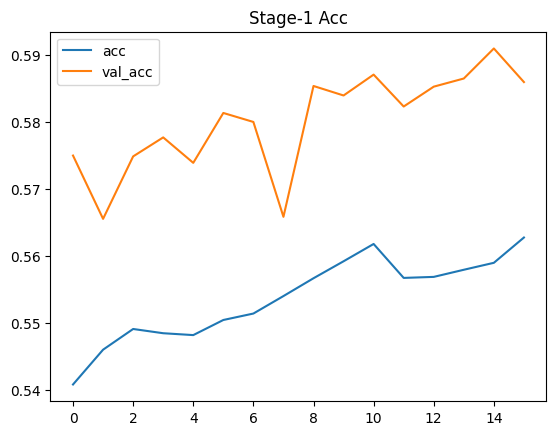

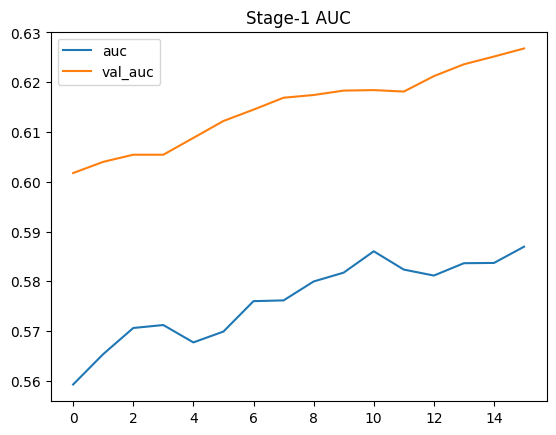

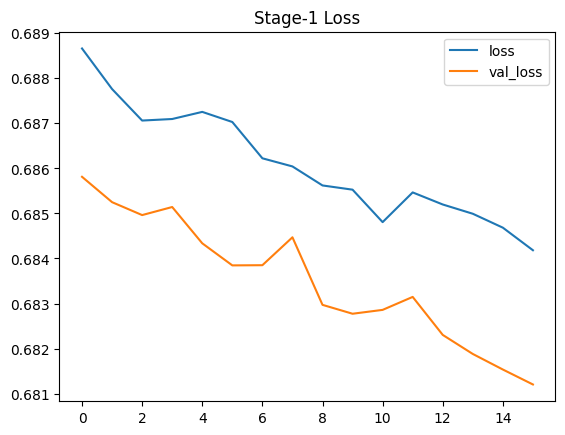

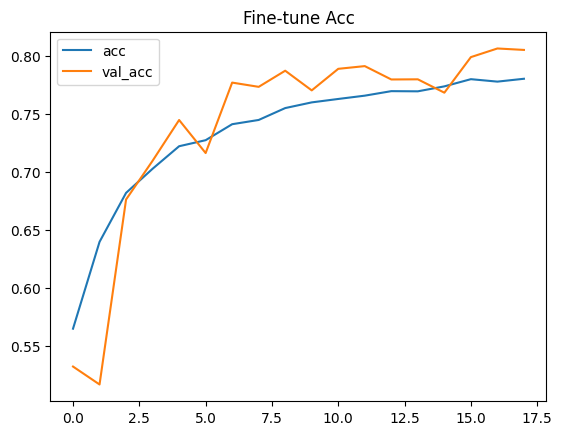

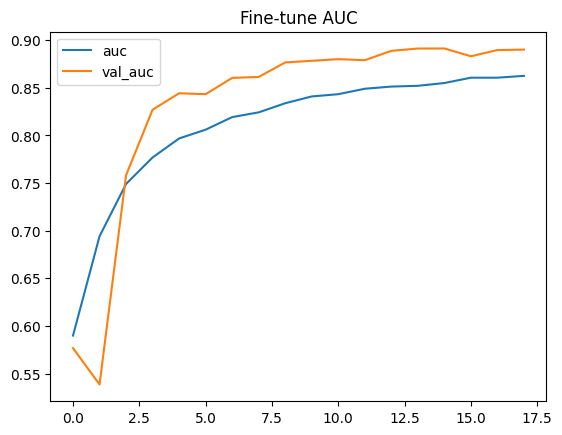

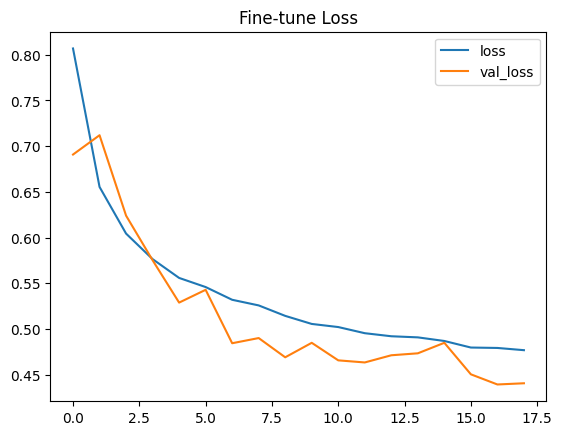

In [ ]:
N_UNFREEZE = 40

base = None
for l in mnv3.layers:
    if isinstance(l, keras.Model) and "MobileNetV3" in l.name:
        base = l
        break

if base is None:
    for l in mnv3.layers:
        if isinstance(l, keras.Model):
            base = l
            break

if base is not None and hasattr(base, "layers"):
    for l in base.layers[:-N_UNFREEZE]:
        l.trainable = False
    for l in base.layers[-N_UNFREEZE:]:
        l.trainable = True
    print("Fine-tuning last", N_UNFREEZE, "layers of base model.")
else:
    print("Warning: base model not found properly.")

In [ ]:
mnv3.compile(
    optimizer=keras.optimizers.Adam(LR_STAGE2),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.03),
    metrics=[
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.AUC(name="auc")
    ]
)

history_ft = mnv3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_2,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

mnv3.save(MNV3_LAST.as_posix())
print("Saved fine-tuned model:", MNV3_LAST)

Loaded best: deepfake_mobilenetv3_best.keras

== Validation ==
              precision    recall  f1-score   support

        Fake     0.7083    0.9085    0.7960     19641
        Real     0.8737    0.6287    0.7312     19787

    accuracy                         0.7681     39428
   macro avg     0.7910    0.7686    0.7636     39428
weighted avg     0.7913    0.7681    0.7635     39428

Confusion Matrix:
 [[17843  1798]
 [ 7347 12440]]
ROC AUC: 0.8911585682462475

== Test ==
              precision    recall  f1-score   support

        Fake     0.5944    0.9080    0.7185      5492
        Real     0.7992    0.3713    0.5071      5413

    accuracy                         0.6416     10905
   macro avg     0.6968    0.6397    0.6128     10905
weighted avg     0.6961    0.6416    0.6135     10905

Confusion Matrix:
 [[4987  505]
 [3403 2010]]
ROC AUC: 0.7544038158252186
Exported: deepfake_mobilenetv3_best.keras labels.json: {'Fake': 0, 'Real': 1}


In [ ]:
def plot_history(h, title="Training"):
    if h is None:
        return

    plt.figure(figsize=(6,4))
    plt.plot(h.history["acc"])
    plt.plot(h.history["val_acc"])
    plt.title(f"{title} Accuracy")
    plt.legend(["train", "val"])
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(h.history["auc"])
    plt.plot(h.history["val_auc"])
    plt.title(f"{title} AUC")
    plt.legend(["train", "val"])
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(h.history["loss"])
    plt.plot(h.history["val_loss"])
    plt.title(f"{title} Loss")
    plt.legend(["train", "val"])
    plt.show()

plot_history(history, "Stage 1")
plot_history(history_ft, "Fine-tune")

In [ ]:
best = keras.models.load_model(MNV3_BEST.as_posix(), compile=False)
print("Loaded best model:", MNV3_BEST.name)

Exported: deepfake_mobilenetv3_best.keras labels.json: {'Fake': 0, 'Real': 1}


In [ ]:
IDX2LABEL = {0: "Fake", 1: "Real"}
LABEL2IDX = {"Fake": 0, "Real": 1}

def collect_raw_scores(ds, model):
    y_true, y_score = [], []
    for x, y in ds:
        p = model.predict(x, verbose=0).ravel()
        y_true.append(y.numpy())
        y_score.append(p)
    y_true = np.concatenate(y_true)
    y_score = np.concatenate(y_score)
    return y_true, y_score

def youden_best_threshold(y_true, y_score):
    thresholds = np.unique(np.round(y_score, 4))
    best_t, best_j = 0.5, -999

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)

        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))

        tpr = tp / max(1, tp + fn)
        fpr = fp / max(1, fp + tn)
        j = tpr - fpr

        if j > best_j:
            best_j = j
            best_t = float(t)

    return best_t, best_j

def calibrate_sigmoid_polarity_and_threshold(model, val_ds):
    y_true, y_raw = collect_raw_scores(val_ds, model)

    mean_fake = float(np.mean(y_raw[y_true == 0])) if np.any(y_true == 0) else np.nan
    mean_real = float(np.mean(y_raw[y_true == 1])) if np.any(y_true == 1) else np.nan

    print("Mean sigmoid on Fake images:", round(mean_fake, 4))
    print("Mean sigmoid on Real images:", round(mean_real, 4))

    if mean_real >= mean_fake:
        positive_label = "Real"
        p_real = y_raw.copy()
        print("\nDetected: sigmoid output ≈ P(Real)")
    else:
        positive_label = "Fake"
        p_real = 1.0 - y_raw
        print("\nDetected: sigmoid output ≈ P(Fake)")

    best_t, best_j = youden_best_threshold(y_true, p_real)

    print("Best threshold for Real:", round(best_t, 4))
    print("Best Youden J:", round(best_j, 4))

    calib = {
        "sigmoid_means": {
            "Fake": mean_fake,
            "Real": mean_real
        },
        "sigmoid_positive_label": positive_label,
        "best_threshold_for_real": float(best_t)
    }
    return calib

In [ ]:
calib = calibrate_sigmoid_polarity_and_threshold(best, val_ds)

with open(CALIB_JSON, "w") as f:
    json.dump(calib, f, indent=2)

print(json.dumps(calib, indent=2))
print("Saved calibration to:", CALIB_JSON)

In [ ]:
def evaluate_with_calibration(name, ds, model, calib):
    y_true, y_raw = collect_raw_scores(ds, model)

    if calib["sigmoid_positive_label"] == "Real":
        p_real = y_raw
    else:
        p_real = 1.0 - y_raw

    thr = calib["best_threshold_for_real"]
    y_pred = (p_real >= thr).astype(int)

    print(f"\n===== {name} =====")
    print("Threshold used:", round(thr, 4))
    print(classification_report(y_true, y_pred, target_names=["Fake", "Real"], digits=4))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

    try:
        auc = roc_auc_score(y_true, p_real)
        print("ROC AUC:", round(auc, 4))
    except Exception as e:
        print("ROC AUC error:", e)

evaluate_with_calibration("Validation", val_ds, best, calib)
evaluate_with_calibration("Test", test_ds, best, calib)

In [ ]:
import cv2

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def crop_largest_face(rgb_img):
    gray = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    if len(faces) == 0:
        return rgb_img

    x, y, w, h = max(faces, key=lambda r: r[2] * r[3])
    pad = int(0.15 * max(w, h))

    x0 = max(0, x - pad)
    y0 = max(0, y - pad)
    x1 = min(rgb_img.shape[1], x + w + pad)
    y1 = min(rgb_img.shape[0], y + h + pad)

    return rgb_img[y0:y1, x0:x1]

In [ ]:
def predict_image(img_path, model=None, calib=None, face_crop=True, show_image=True):
    model = model or best

    if calib is None:
        with open(CALIB_JSON, "r") as f:
            calib = json.load(f)

    img = Image.open(img_path).convert("RGB")
    rgb = np.array(img)

    if face_crop:
        rgb = crop_largest_face(rgb)

    if show_image:
        plt.figure(figsize=(4,4))
        plt.imshow(rgb)
        plt.axis("off")
        plt.title("Image used for prediction")
        plt.show()

    rgb = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
    x = np.expand_dims(rgb, axis=0)

    # DO NOT divide by 255 here
    # model already contains preprocessing layers
    raw = float(model.predict(x, verbose=0).ravel()[0])

    if calib["sigmoid_positive_label"] == "Real":
        p_real = raw
    else:
        p_real = 1.0 - raw

    p_fake = 1.0 - p_real
    thr = float(calib["best_threshold_for_real"])

    pred = "Real" if p_real >= thr else "Fake"
    conf = p_real if pred == "Real" else p_fake

    result = {
        "raw_sigmoid": round(raw, 6),
        "p_fake": round(float(p_fake), 6),
        "p_real": round(float(p_real), 6),
        "threshold_for_real": round(thr, 6),
        "prediction": pred,
        "confidence": round(float(conf), 6),
        "face_crop": face_crop
    }

    return result

In [ ]:
best.save(MNV3_BEST.as_posix())

with open(LABELS_JSON, "w") as f:
    json.dump(labels_map, f, indent=2)

with open(CALIB_JSON, "w") as f:
    json.dump(calib, f, indent=2)

print("Exported:")
print(" -", MNV3_BEST)
print(" -", LABELS_JSON)
print(" -", CALIB_JSON)